# Когортный анализ Retention

**Проект по анализу клиентского поведения**  
Датасет: `Online Retail` (UCI Machine Learning) — транзакции интернет-магазина за 2010-2011 гг.

**Цель анализа:**  
Оценить, как меняется лояльность клиентов с течением времени — какой процент покупателей возвращается в первый, второй, третий месяц после первой покупки.

**Инструменты:** `pandas`, `sqlite3`, `seaborn`, `matplotlib`

## 1. Импортируем и читаем данные

In [8]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_excel('../datasets/online_retail.xlsx')
df.to_csv('../datasets/online_retail.csv', index=False)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## 2. Очистка данных и загрузка в SQLite

Удаляем:
- Строки с пустым `CustomerID`
- Возвраты (`InvoiceNo` начинается с 'C')
- Некорректные значения `Quantity` и `UnitPrice` (≤ 0)

In [9]:
conn = sqlite3.connect('../datasets/retail.db')
cursor = conn.cursor()  # ← ЭТО ДОБАВИТЬ

df = pd.read_csv('../datasets/online_retail.csv')

df = (df
    .dropna(subset=['CustomerID'])
    .loc[~df['InvoiceNo'].astype(str).str.startswith('C')]
    .loc[df['Quantity'] > 0]
    .loc[df['UnitPrice'] > 0]
)

df.to_sql('retail', conn, if_exists='replace', index=False)

print(f"Загружено: {len(df):,} строк, {df['CustomerID'].nunique():,} покупателей")
print(f"Таблица 'retail' → ../datasets/retail.db")

Загружено: 397,884 строк, 4,338 покупателей
Таблица 'retail' → ../datasets/retail.db


## 3. Формирование когорт

Когорта = месяц первой покупки клиента.  
Для каждого покупателя определяем:
- `first_purchase_date` — дата первой покупки
- `cohort_month` — месяц первой покупки 

In [10]:
conn = sqlite3.connect('../datasets/retail.db')
df.to_sql('retail', conn, if_exists='replace', index=False)

print(f"Загружено: {len(df):,} строк, {df['CustomerID'].nunique():,} покупателей")
print(f"Таблица 'retail' → ../datasets/retail.db")

cursor.execute("""
CREATE TABLE IF NOT EXISTS cohort_dates AS
SELECT 
    CustomerID,
    MIN(DATE(InvoiceDate)) AS first_purchase_date,
    STRFTIME('%Y-%m', MIN(DATE(InvoiceDate))) AS cohort_month
FROM retail
GROUP BY CustomerID
""")
conn.commit()

print("\nТАБЛИЦА КОГОРТ (первая покупка покупателей)")
cohort_sample = pd.read_sql_query("SELECT * FROM cohort_dates LIMIT 10", conn)

display(cohort_sample)

total_cohorts = pd.read_sql_query("SELECT COUNT(*) as total FROM cohort_dates", conn).iloc[0, 0]
unique_months = pd.read_sql_query("SELECT COUNT(DISTINCT cohort_month) as months FROM cohort_dates", conn).iloc[0, 0]

print(f"\nСтатистика:")
print(f"   • Всего уникальных покупателей: {total_cohorts:,}")
print(f"   • Количество уникальных когорт (месяцев): {unique_months}")

Загружено: 397,884 строк, 4,338 покупателей
Таблица 'retail' → ../datasets/retail.db

ТАБЛИЦА КОГОРТ (первая покупка покупателей)


,CustomerID,first_purchase_date,cohort_month
0,12346.0,2011-01-18,2011-01
1,12347.0,2010-12-07,2010-12
2,12348.0,2010-12-16,2010-12
3,12349.0,2011-11-21,2011-11
4,12350.0,2011-02-02,2011-02
5,12352.0,2011-02-16,2011-02
6,12353.0,2011-05-19,2011-05
7,12354.0,2011-04-21,2011-04
8,12355.0,2011-05-09,2011-05
9,12356.0,2011-01-18,2011-01



Статистика:
   • Всего уникальных покупателей: 4,338
   • Количество уникальных когорт (месяцев): 13


## 4. Присоединение когортной информации к транзакциям

Добавляем для каждой покупки номер месяца жизни клиента (`month_number`):  
0 — месяц первой покупки, 1 — следующий месяц, и т.д.

In [11]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS cohort_dates AS
SELECT 
    CustomerID,
    MIN(DATE(InvoiceDate)) AS first_purchase_date,
    STRFTIME('%Y-%m', MIN(DATE(InvoiceDate))) AS cohort_month
FROM retail
GROUP BY CustomerID
""")
conn.commit()

print("ТАБЛИЦА КОГОРТ (первая покупка покупателей)")

cohort_sample = pd.read_sql_query("SELECT * FROM cohort_dates LIMIT 10", conn)

display(cohort_sample)

total_cohorts = pd.read_sql_query("SELECT COUNT(*) as total FROM cohort_dates", conn).iloc[0, 0]
unique_months = pd.read_sql_query("SELECT COUNT(DISTINCT cohort_month) as months FROM cohort_dates", conn).iloc[0, 0]

print(f"\nСтатистика:")
print(f"   • Всего уникальных покупателей: {total_cohorts:,}")
print(f"   • Количество уникальных когорт (месяцев): {unique_months}")

ТАБЛИЦА КОГОРТ (первая покупка покупателей)


,CustomerID,first_purchase_date,cohort_month
0,12346.0,2011-01-18,2011-01
1,12347.0,2010-12-07,2010-12
2,12348.0,2010-12-16,2010-12
3,12349.0,2011-11-21,2011-11
4,12350.0,2011-02-02,2011-02
5,12352.0,2011-02-16,2011-02
6,12353.0,2011-05-19,2011-05
7,12354.0,2011-04-21,2011-04
8,12355.0,2011-05-09,2011-05
9,12356.0,2011-01-18,2011-01



Статистика:
   • Всего уникальных покупателей: 4,338
   • Количество уникальных когорт (месяцев): 13


## 5. Расчёт Retention

Для каждой когорты считаем, сколько уникальных покупателей совершили покупку в каждом месяце жизни (0–12 месяцев).

In [12]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS retail_with_cohort AS
SELECT 
    r.*,
    c.cohort_month,
    c.first_purchase_date,
    CAST((JULIANDAY(DATE(r.InvoiceDate)) - JULIANDAY(c.first_purchase_date)) / 30.44 AS INTEGER) AS month_number
FROM retail r
JOIN cohort_dates c ON r.CustomerID = c.CustomerID
""")
conn.commit()

print("Таблица 'retail_with_cohort' создана")

retention_query = """
SELECT 
    cohort_month,
    month_number,
    COUNT(DISTINCT CustomerID) AS customers
FROM retail_with_cohort
WHERE month_number <= 12
GROUP BY cohort_month, month_number
ORDER BY cohort_month, month_number
"""

retention_df = pd.read_sql_query(retention_query, conn)

print("\nСЫРЫЕ ДАННЫЕ RETENTION (по месяцам жизни когорт)")
display(retention_df.head(15))

print(f"\nСтатистика:")
print(f"   • Всего строк в выборке: {len(retention_df)}")
print(f"   • Количество когорт: {retention_df['cohort_month'].nunique()}")
print(f"   • Максимальный месяц жизни: {retention_df['month_number'].max()}")

Таблица 'retail_with_cohort' создана

СЫРЫЕ ДАННЫЕ RETENTION (по месяцам жизни когорт)


,cohort_month,month_number,customers
0,2010-12,0,885
1,2010-12,1,322
2,2010-12,2,320
3,2010-12,3,347
4,2010-12,4,300
5,2010-12,5,338
6,2010-12,6,323
7,2010-12,7,299
8,2010-12,8,312
9,2010-12,9,344



Статистика:
   • Всего строк в выборке: 90
   • Количество когорт: 13
   • Максимальный месяц жизни: 12


## 6. Когортная таблица Retention (в процентах)

In [13]:
cohort_pivot = retention_df.pivot(index='cohort_month', columns='month_number', values='customers')
cohort_size = cohort_pivot.iloc[:, 0]

# переводим в проценты
retention_table = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)

print("КОГОРТНЫЙ RETENTION (%)")
print("Сколько процентов покупателей вернулись в каждый месяц жизни")
display(retention_table)

print(f"\nКраткая статистика:")
print(f"   • Количество когорт: {len(retention_table)}")
print(f"   • Горизонт анализа: {len(retention_table.columns)} месяцев")
print(f"   • Средний Retention на 3-м месяце: {retention_table[3].mean():.1f}% (если есть данные)")

КОГОРТНЫЙ RETENTION (%)
Сколько процентов покупателей вернулись в каждый месяц жизни


month_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,100.0,36.4,36.2,39.2,33.9,38.2,36.5,33.8,35.3,38.9,41.8,51.4,8.6
2011-01,100.0,25.2,28.8,27.8,27.3,27.6,24.9,25.7,32.1,35.0,25.2,0.5,NaN
2011-02,100.0,21.6,25.8,27.9,21.1,27.1,26.1,24.7,29.5,22.4,0.5,NaN,NaN
2011-03,100.0,18.1,23.7,21.9,18.8,20.4,25.2,25.2,21.2,3.1,NaN,NaN,NaN
2011-04,100.0,25.0,17.7,20.7,17.3,21.3,24.0,22.3,2.0,NaN,NaN,NaN,NaN
2011-05,100.0,19.4,15.5,19.7,25.0,22.5,25.0,1.1,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,15.3,19.4,23.1,28.1,27.7,2.1,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.6,21.3,22.9,23.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,21.3,29.0,21.9,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Краткая статистика:
   • Количество когорт: 13
   • Горизонт анализа: 13 месяцев
   • Средний Retention на 3-м месяце: 22.6% (если есть данные)


## 7. Визуализация

### i. Тепловая карта Retention

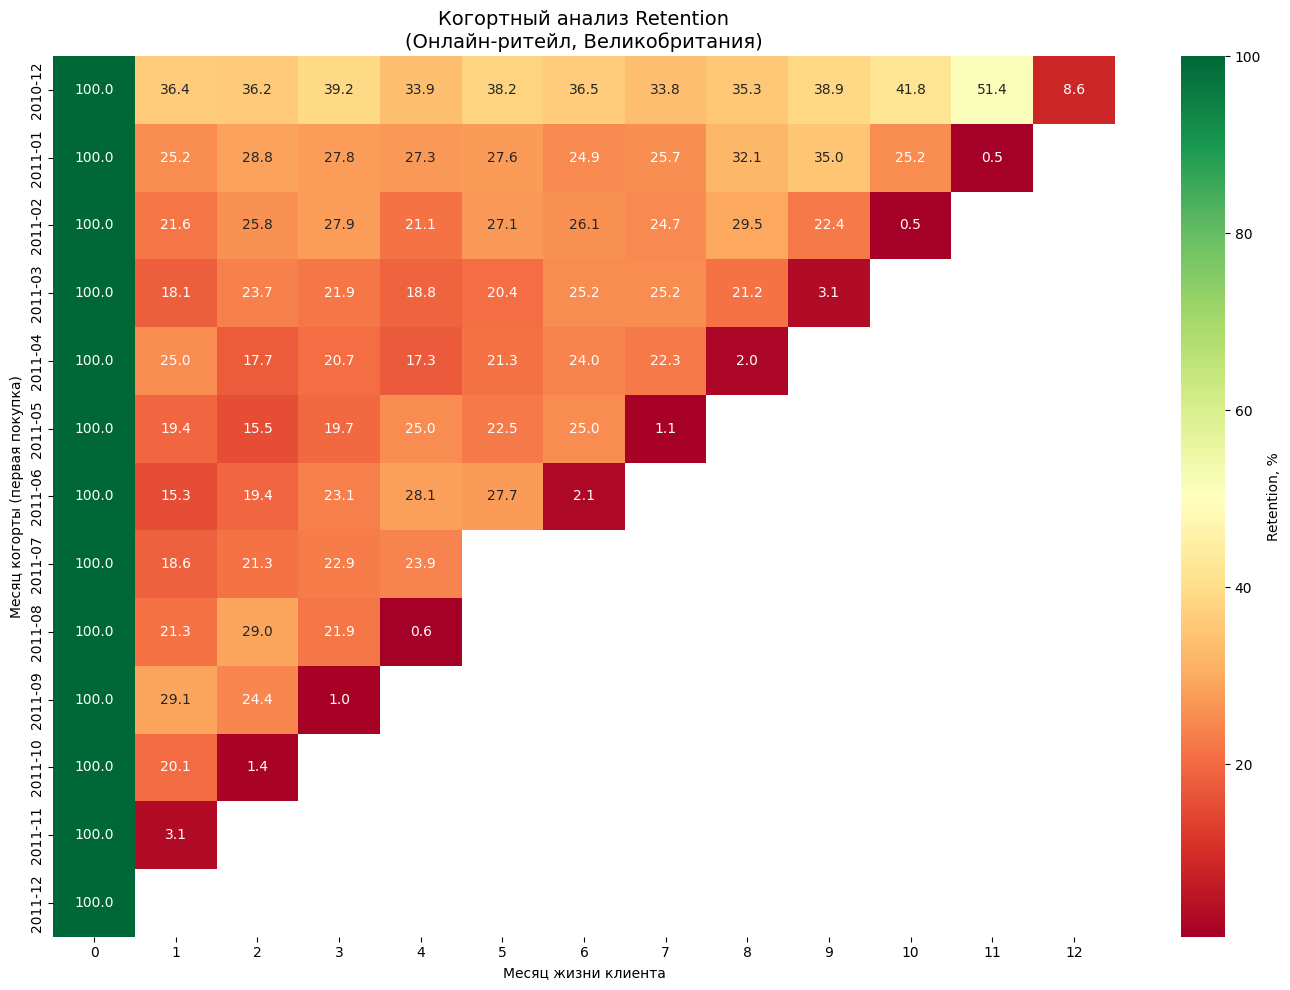

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Retention, %'}
)
plt.title('Когортный анализ Retention\n(Онлайн-ритейл, Великобритания)', fontsize=14)
plt.xlabel('Месяц жизни клиента')
plt.ylabel('Месяц когорты (первая покупка)')
plt.tight_layout()
plt.show()

### ii. Кривые Retention по когортам (первые 6)

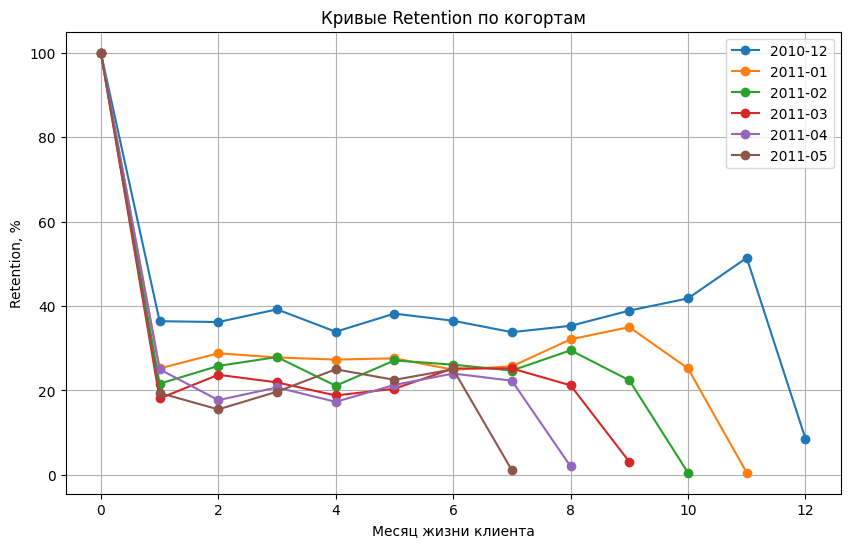

In [15]:
plt.figure(figsize=(10, 6))
for cohort in retention_table.index[:6]:
    plt.plot(
        retention_table.columns, 
        retention_table.loc[cohort], 
        marker='o', 
        label=cohort
    )

plt.xlabel('Месяц жизни клиента')
plt.ylabel('Retention, %')
plt.title('Кривые Retention по когортам')
plt.legend()
plt.grid(True)
plt.show()

## 8. Итоговая таблица

In [16]:
# раскраска таблицы
def style_retention(df):
    return df.style.background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=100).format("{:.1f}%")

styled_table = style_retention(retention_table)
display(styled_table)

month_number,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,100.0%,36.4%,36.2%,39.2%,33.9%,38.2%,36.5%,33.8%,35.3%,38.9%,41.8%,51.4%,8.6%
2011-01,100.0%,25.2%,28.8%,27.8%,27.3%,27.6%,24.9%,25.7%,32.1%,35.0%,25.2%,0.5%,nan%
2011-02,100.0%,21.6%,25.8%,27.9%,21.1%,27.1%,26.1%,24.7%,29.5%,22.4%,0.5%,nan%,nan%
2011-03,100.0%,18.1%,23.7%,21.9%,18.8%,20.4%,25.2%,25.2%,21.2%,3.1%,nan%,nan%,nan%
2011-04,100.0%,25.0%,17.7%,20.7%,17.3%,21.3%,24.0%,22.3%,2.0%,nan%,nan%,nan%,nan%
2011-05,100.0%,19.4%,15.5%,19.7%,25.0%,22.5%,25.0%,1.1%,nan%,nan%,nan%,nan%,nan%
2011-06,100.0%,15.3%,19.4%,23.1%,28.1%,27.7%,2.1%,nan%,nan%,nan%,nan%,nan%,nan%
2011-07,100.0%,18.6%,21.3%,22.9%,23.9%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2011-08,100.0%,21.3%,29.0%,21.9%,0.6%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


## Бизнес-выводы

### Ключевые инсайты

1. **Сезонный паттерн**  
   Когорта декабря 2010 показывает аномально высокий retention на 11-м месяце жизни (51.4%) — клиенты возвращаются перед следующим Новым годом.  
   ➜ *Рекомендация:* запускать ретаргетинговую кампанию в ноябре для всех, кто сделал первую покупку в декабре прошлого года.

2. **Критический отток на 2–3 месяце**  
   Большинство когорт теряют 60–75% клиентов уже к 3-му месяцу.  
   ➜ *Рекомендация:* внедрить welcome-последовательности (email/telegram) и программу лояльности на 2-й месяц после первой покупки.

3. **Слабые когорты**  
   Когорты 2011-08, 2011-10, 2011-11 показывают практически нулевой retention на 2–4 месяце (<5%).  
   ➜ *Рекомендация:* проанализировать качество трафика в эти периоды (возможно, привлекались нецелевые пользователи).

4. **Сильные когорты**  
   2010-12 и 2011-01 — лучшие по долгосрочному retention.  
   ➜ *Рекомендация:* изучить маркетинговые активности этих месяцев (акции, каналы привлечения) и масштабировать на другие периоды.

### Что делать бизнесу?

| Действие | Срок | Ожидаемый эффект |
|----------|------|------------------|
| Настроить триггерные рассылки на 30, 60, 90 день после первой покупки | 2 недели | +10–15% retention на 3-м месяце |
| Запустить предновогоднюю кампанию для когорты 2010-12 | ноябрь | конверсия в повторные покупки |
| Проанализировать каналы привлечения в проблемных месяцах | 1 месяц | снижение CAC, улучшение качества трафика |
| Внедрить систему лояльности (баллы/скидки за возврат) | 2 месяца | рост LTV на 20% |